# Data Exploration

## Input and target variables

**X** contains columns 1–30: chemical composition, welding parameters, and post-weld heat treatment. **Y** contains the measured properties in columns 31–38; columns 39–43 describe microstructure and can be considered additional targets. We exclude **Weld ID** (column 44), since it is only an identifier. The dataset has no "good/bad" label, so classification would require quality thresholds defined by an applicable standard or project requirements.

In [5]:
import matplotlib.pyplot as plt
from pathlib import Path
import json
import pandas as pd

In [6]:
# N est le code utilisé dans le fichier pour signaler une valeur non renseignée.
colonnes = json.loads(Path("context/columns.json").read_text(encoding="utf-8"))
noms_colonnes = [
    f"{numero}. {infos['label']}"
    for numero, infos in sorted(colonnes.items(), key=lambda element: int(element[0]))
]

df = pd.read_csv(
    Path("Data/welddb.data"),
    sep=r"\s+",
    header=None,
    names=noms_colonnes,
    na_values=["N"],
)

print(f"Dimensions de la base : {df.shape[0]} lignes et {df.shape[1]} colonnes")
display(df.head())

# Lignes identiques sur toutes les colonnes
lignes_dupliquees = df[df.duplicated(keep=False)]
print(f"Nombre de lignes dupliquées : {df.duplicated().sum()}")
display(lignes_dupliquees)

# Valeurs manquantes par colonne et colonnes complètement vides
valeurs_manquantes = df.isna().sum().sort_values(ascending=False)
print("Valeurs manquantes par colonne :")
display(valeurs_manquantes[valeurs_manquantes > 0])

colonnes_vides = df.columns[df.isna().all()].tolist()
print("Colonnes complètement vides :", colonnes_vides)


Dimensions de la base : 1652 lignes et 44 colonnes


,1. Carbon concentration,2. Silicon concentration,3. Manganese concentration,4. Sulphur concentration,5. Phosphorus concentration,6. Nickel concentration,7. Chromium concentration,8. Molybdenum concentration,9. Vanadium concentration,10. Copper concentration,...,35. Charpy temperature,36. Charpy impact toughness,37. Hardness,38. 50% FATT,39. Primary ferrite in microstructure,40. Ferrite with second phase,41. Acicular ferrite,42. Martensite,43. Ferrite with carbide aggregate,44. Weld ID
0,0.037,0.30,0.65,0.008,0.012,0.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Evans-Ni/CMn-1990/1991-0Aaw
1,0.037,0.30,0.65,0.008,0.012,0.0,NaN,NaN,NaN,NaN,...,-28.0,100.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Evans-Ni/CMn-1990/1991-0Aawch
2,0.037,0.30,0.65,0.008,0.012,0.0,NaN,NaN,NaN,NaN,...,-38.0,100.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Evans-Ni/CMn-1990/1991-0Aht
3,0.037,0.31,1.03,0.007,0.014,0.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Evans-Ni/CMn-1990/1991-0Baw
4,0.037,0.31,1.03,0.007,0.014,0.0,NaN,NaN,NaN,NaN,...,-48.0,100.0,NaN,NaN,32,28.0,40.0,0.0,0.0,Evans-Ni/CMn-1990/1991-0Bawch


Nombre de lignes dupliquées : 0


,1. Carbon concentration,2. Silicon concentration,3. Manganese concentration,4. Sulphur concentration,5. Phosphorus concentration,6. Nickel concentration,7. Chromium concentration,8. Molybdenum concentration,9. Vanadium concentration,10. Copper concentration,...,35. Charpy temperature,36. Charpy impact toughness,37. Hardness,38. 50% FATT,39. Primary ferrite in microstructure,40. Ferrite with second phase,41. Acicular ferrite,42. Martensite,43. Ferrite with carbide aggregate,44. Weld ID


Valeurs manquantes par colonne :


38. 50% FATT                                1621
12. Tungsten concentration                  1577
42. Martensite                              1563
43. Ferrite with carbide aggregate          1563
40. Ferrite with second phase               1562
41. Acicular ferrite                        1562
39. Primary ferrite in microstructure       1554
11. Cobalt concentration                    1523
37. Hardness                                1514
20. Arsenic concentration                   1418
21. Antimony concentration                  1392
19. Tin concentration                       1356
17. Boron concentration                     1148
10. Copper concentration                    1074
6. Nickel concentration                      955
33. Elongation                               952
34. Reduction of Area                        947
32. Ultimate tensile strength                914
18. Niobium concentration                    900
31. Yield strength                           872
7. Chromium concentr

Colonnes complètement vides : []


The columns 38-42-43-40-41-39 are at least empty for 3 quarters of the instances. It is too empty to use as a training dataset, so we choose to not predict those characteristics and ignore the columns.
For the features, we also have 7 columns at least half empty (12-11-20-21-19-17-10) so we also choose to drop them as features.

Potential numeric outliers (IQR rule):


,outlier_count,outlier_percent,lower_bound,upper_bound
27. Interpass temperature,550,33.29,200.000000,200.000000
22. Current,310,18.77,-25.000000,495.000000
15. Nitrogen concentration,166,10.05,20.250000,158.250000
26. Heat input,161,9.75,-0.500000,3.500000
13. Oxygen concentration,156,9.44,218.500000,622.500000
2. Silicon concentration,153,9.26,0.135000,0.495000
6. Nickel concentration,126,7.63,-0.390000,0.650000
4. Sulphur concentration,126,7.63,0.000000,0.016000
7. Chromium concentration,120,7.26,-3.450000,5.750000
23. Voltage,83,5.02,7.500000,43.500000


Non-numeric tokens in numeric input columns:


4. Sulphur concentration         7
8. Molybdenum concentration      2
9. Vanadium concentration      308
10. Copper concentration        14
11. Cobalt concentration        21
12. Tungsten concentration      12
14. Titanium concentration      70
15. Nitrogen concentration      59
16. Aluminium concentration    403
17. Boron concentration        419
18. Niobium concentration      299
19. Tin concentration            5
20. Arsenic concentration        8
21. Antimony concentration       6
27. Interpass temperature       38
dtype: int64

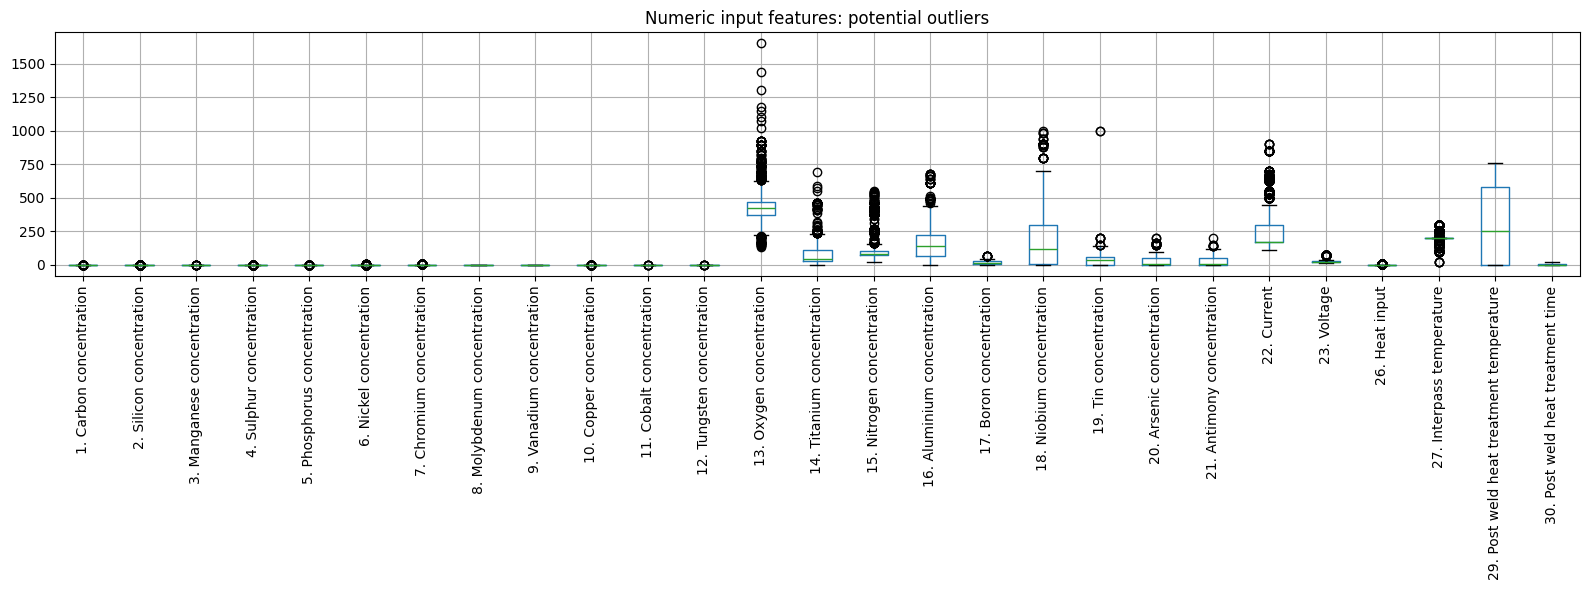

Numeric feature scales (no scaling applied):


,min,max,range,standard_deviation
13. Oxygen concentration,132.000,1650.00,1518.000,147.483825
19. Tin concentration,0.000,1000.00,1000.000,89.606313
18. Niobium concentration,0.000,1000.00,1000.000,263.347250
22. Current,115.000,900.00,785.000,192.560955
29. Post weld heat treatment temperature,0.000,760.00,760.000,285.498003
14. Titanium concentration,0.000,690.00,690.000,100.110707
16. Aluminium concentration,0.004,680.00,679.996,155.781121
15. Nitrogen concentration,21.000,552.00,531.000,95.902889
27. Interpass temperature,20.000,300.00,280.000,39.550604
21. Antimony concentration,0.000,200.00,200.000,35.825789


\n24. AC or DC: 3 observed levels
Missing values: 215
Value frequencies:


24. AC or DC
DC           1395
<MISSING>     215
AC             42
Name: count, dtype: int64

Rare levels (fewer than 16 rows):


...

25. Electrode polarity
-    7
Name: count, dtype: int64

\n28. Type of weld: 10 observed levels
Missing values: 0
Value frequencies:


28. Type of weld
MMA      1140
SA        261
TSA        87
FCA        87
ShMA       40
NGSAW      18
NGGMA       7
SAA         4
GMAA        4
GTAA        4
Name: count, dtype: int64

Rare levels (fewer than 16 rows):


28. Type of weld
NGGMA    7
SAA      4
GMAA     4
GTAA     4
Name: count, dtype: int64

In [ ]:
# Use the schema in columns.json to select documented input features.
seuil_manquants = 50
metadonnees_entrees = {
    int(numero): infos
    for numero, infos in colonnes.items()
    if infos["role"] == "input"
}
colonnes_exclues = {
    numero: infos
    for numero, infos in metadonnees_entrees.items()
    if infos["missing"]["pct"] >= seuil_manquants
}

print(f"Input columns excluded for >= {seuil_manquants}% missing values:")
display(pd.DataFrame([
    {
        "column": numero,
        "feature": infos["label"],
        "missing_percent_in_schema": infos["missing"]["pct"],
    }
    for numero, infos in colonnes_exclues.items()
]).set_index("column"))

# Inspect remaining inputs only; the original DataFrame is not modified.
colonnes_a_examiner = {
    numero: infos
    for numero, infos in metadonnees_entrees.items()
    if numero not in colonnes_exclues
}
X_a_examiner = df[[f"{numero}. {infos['label']}" for numero, infos in colonnes_a_examiner.items()]].copy()
colonnes_categorielles = [
    f"{numero}. {infos['label']}"
    for numero, infos in colonnes_a_examiner.items()
    if infos["type"] == "categorical"
]
colonnes_numeriques = [
    f"{numero}. {infos['label']}"
    for numero, infos in colonnes_a_examiner.items()
    if infos["type"].startswith("continuous")
]

# Parse what is plainly numeric. Special encodings stay visible in the token report.
numerique = X_a_examiner[colonnes_numeriques].apply(pd.to_numeric, errors="coerce")

# 1. Flag potential outliers with the IQR rule; do not remove or cap them.
q1 = numerique.quantile(0.25)
q3 = numerique.quantile(0.75)
iqr = q3 - q1
borne_basse = q1 - 1.5 * iqr
borne_haute = q3 + 1.5 * iqr
masque_outliers = numerique.lt(borne_basse) | numerique.gt(borne_haute)

resume_outliers = pd.DataFrame({
    "feature": [colonnes[str(numero)]["label"] for numero in range(1, 1)],
})
resume_outliers = pd.DataFrame({
    "outlier_count": masque_outliers.sum(),
    "outlier_percent_of_numeric_values": (
        masque_outliers.sum() / numerique.notna().sum() * 100
    ).round(2),
    "lower_bound": borne_basse,
    "upper_bound": borne_haute,
})
resume_outliers["feature"] = [
    colonnes_a_examiner[int(name.split(".", 1)[0])]["label"]
    for name in resume_outliers.index
]
resume_outliers["unit"] = [
    colonnes_a_examiner[int(name.split(".", 1)[0])]["unit"]
    for name in resume_outliers.index
]
print("Potential numeric outliers (IQR rule; for review only):")
display(
    resume_outliers[resume_outliers["outlier_count"] > 0]
    .sort_values("outlier_count", ascending=False)
)

# Show tokens that could not be parsed and the schema notes explaining their format.
token_rows = []
for column in colonnes_numeriques:
    invalid = X_a_examiner[column].notna() & numerique[column].isna()
    if invalid.any():
        numero = int(column.split(".", 1)[0])
        infos = colonnes_a_examiner[numero]
        token_rows.append({
            "column": numero,
            "feature": infos["label"],
            "count": int(invalid.sum()),
            "examples_in_data": X_a_examiner.loc[invalid, column].astype(str).unique()[:8].tolist(),
            "documented_tokens": infos["observed"].get("censored_tokens", infos["observed"].get("non_numeric_tokens", [])),
            "schema_note": infos["observed"].get("note", ""),
        })
print("Non-numeric tokens in numeric inputs (check schema notes before parsing):")
display(pd.DataFrame(token_rows).set_index("column") if token_rows else pd.DataFrame())

# Boxplots help inspect the numeric ranges; they do not change any values.
plt.figure(figsize=(16, 6))
numerique.boxplot(rot=90)
plt.title("Numeric input features: potential outliers")
plt.tight_layout()
plt.show()

# 2. Compare measured ranges with the units and ranges documented in the schema.
echelle_rows = []
for column in colonnes_numeriques:
    numero = int(column.split(".", 1)[0])
    infos = colonnes_a_examiner[numero]
    observed = infos["observed"]
    echelle_rows.append({
        "column": numero,
        "feature": infos["label"],
        "unit": infos["unit"],
        "schema_missing_percent": infos["missing"]["pct"],
        "schema_min": observed.get("min", observed.get("numeric_range", {}).get("min")),
        "schema_max": observed.get("max", observed.get("numeric_range", {}).get("max")),
        "data_min": numerique[column].min(),
        "data_max": numerique[column].max(),
        "data_range": numerique[column].max() - numerique[column].min(),
        "data_std": numerique[column].std(),
        "schema_note": observed.get("note", ""),
    })
resume_echelles = pd.DataFrame(echelle_rows).set_index("column").sort_values(
    "data_range", ascending=False
)
print("Feature scales before scaling (no scaling applied):")
display(resume_echelles)

# 3. Compare observed categories with categories documented in columns.json.
for column in colonnes_categorielles:
    numero = int(column.split(".", 1)[0])
    infos = colonnes_a_examiner[numero]
    frequences = X_a_examiner[column].value_counts(dropna=False)
    categories_documentees = infos["observed"].get("categories", {})
    comparaison = pd.DataFrame({
        "count_in_data": frequences,
        "count_in_schema": pd.Series(categories_documentees),
    }).fillna(0).astype(int)
    rare_limit = max(5, int(0.01 * len(X_a_examiner)))
    print(f"\\n{numero}. {infos['label']} ({infos['details']})")
    print(f"Missing values: {X_a_examiner[column].isna().sum()} (schema: {infos['missing']['pct']}%)")
    print(f"Rare categories (< {rare_limit} rows):")
    display(comparaison[comparaison["count_in_data"] < rare_limit])
    print("Category counts: data compared with columns.json")
    display(comparaison)
    if infos["observed"].get("note"):
        print("Schema note:", infos["observed"]["note"])


## Preprocessing step 1 — left-censored `<...` values

In the raw file, a token such as `<0.002` means the element was **below the
detection limit 0.002** (left-censored), not zero and not missing — see the
`censored_tokens` entries in `context/columns.json`. Pandas parses these as
strings, so they must be resolved before any numeric modelling.

**Rule applied** (`preprocessing/decensor.py`): every `<x` token is replaced
by the numeric value `x`, e.g. `<0.002` → `0.002`. This is an **upper-bound
choice** (the true value lies in `[0, x]`); the classic alternative is the
half-limit `x/2`, or a censored-data model. Revisit if rows at detection
limits turn out to drive a model.

**Scope**: the 14 numerical columns whose schema documents censored tokens
(cols 4, 8–12, 14, 16–21, plus col 39 primary ferrite `<1`, which is an output
column). Everything else is out of scope here: `N` stays missing (empty field
in the output), and the other encodings need their own steps (col 15
`NNtotMMres`, col 27 `150-200` range, col 37 hardness `Hv` suffixes).

**Output**: `data/intermediate/decensored.csv` — one row per weld (1652 rows)
with the `weld_id` identifier (column 44) and the converted values of the 14
concerned columns (`colNN_Label` headers). Plain numerics pass through
unchanged; the raw file is never modified.

**Caveats to keep in mind**

- Replaced values pile up exactly at the limits (e.g. 343 Al rows become 5.0,
  395 B rows become 5.0, 266 V rows become 0.0005): expect artificial spikes
  in those distributions.
- Vanadium `<5` (9 rows → `5.0`) is unit-ambiguous per the schema note on col 9
  — flag for review rather than silently trusting it.
- `decensored.csv` is git-ignored intermediate data (see `.gitignore`); only the
  folder structure is tracked. Re-run the cell below to regenerate it.

In [7]:
import csv
import sys
sys.path.insert(0, "preprocessing")
from decensor import main

# Applies '<x' -> x and writes data/intermediate/decensored.csv
counts = main()

# Round-trip check: 1652 data rows, no '<' token left in value columns
rows = list(csv.reader(open("data/intermediate/decensored.csv", encoding="utf-8")))
assert len(rows) == 1653
assert all(not c.startswith("<") for r in rows[1:] for c in r[1:])
print("check: 1652 data rows, no '<' token left, header:", rows[0][:4], "...")

Concerned columns (14): 4, 8, 9, 10, 11, 12, 14, 16, 17, 18, 19, 20, 21, 39
Replacements '<x' -> x per column: col04=7, col08=2, col09=308, col10=14, col11=21, col12=12, col14=70, col16=403, col17=419, col18=299, col19=5, col20=8, col21=6, col39=2 (total 1576)
Wrote data\intermediate\decensored.csv: 1652 rows x 15 columns
Examples (weld_id | column | raw -> new):
  Evans-Al/CMn-1990-<5aw | col09_Vanadium_concentration | <0.0005 -> 0.0005
  Evans-Al/CMn-1990-<5aw | col16_Aluminium_concentration | <5 -> 5.0
  Evans-Al/CMn-1990-<5aw | col17_Boron_concentration | <5 -> 5.0
  Evans-Al/CMn-1990-<5aw | col18_Niobium_concentration | <5 -> 5.0
  Evans-Al/CMn-1990-<5awch1 | col09_Vanadium_concentration | <0.0005 -> 0.0005
  Evans-Al/CMn-1990-<5awch1 | col16_Aluminium_concentration | <5 -> 5.0
  Evans-Al/CMn-1990-<5awch1 | col17_Boron_concentration | <5 -> 5.0
  Evans-Al/CMn-1990-<5awch1 | col18_Niobium_concentration | <5 -> 5.0
check: 1652 data rows, no '<' token left, header: ['weld_id', 'col04

## Preprocessing step 2 — nitrogen `NNtotMMres` encoding

59 rows report nitrogen (col 15) as e.g. `67tot33res`: **NN = total N**,
**MM = residual (filtered) N**, with `nd` when the residual was not
determined — see the schema note on col 15 in `context/columns.json`.

**Rule applied** (`preprocessing/nitrogen_total.py`): keep only the NN total
value, e.g. `67tot33res` → `67` (and `54totndres` → `54`). Total N is the
quantity comparable with the plain numeric reports, while the residual is only
available for a subset of rows. Alternative: split into two features
(total + residual) — revisit if a nitrogen effect shows up in modelling.

**Scope**: only col 15 matches this encoding (scan of all numerical columns).
Plain numerics pass through unchanged, `N` stays missing (empty field).

**Output**: `data/intermediate/nitrogen_total.csv` — one row per weld (1652
rows) with `weld_id` and the converted `col15_Nitrogen_concentration` values.
The raw file is never modified. Like `decensored.csv`, it is git-ignored
intermediate data; re-run the cell below to regenerate it.

**Caveat**: this assumes the plain numeric reports are also totals, consistent
with the column documentation (`ppmw`). The residual information is discarded.

In [8]:
import csv
import sys
sys.path.insert(0, "preprocessing")
from nitrogen_total import main

# Keeps NN from 'NNtotMMres' and writes data/intermediate/nitrogen_total.csv
counts = main()

# Round-trip check: 1652 data rows, no 'tot' token left
rows = list(csv.reader(open("data/intermediate/nitrogen_total.csv", encoding="utf-8")))
assert len(rows) == 1653
assert all("tot" not in c for r in rows[1:] for c in r[1:])
print("check: 1652 data rows, no 'tot' token left, header:", rows[0])

Concerned columns: [15] (tokens matching NNtotMMres)
Replacements NNtotMMres -> NN: 48tot18res-> 48 (x7), 50tot17res-> 50 (x7), 52tot18res-> 52 (x7), 54tot24res-> 54 (x7), 54totndres-> 54 (x6), 61tot34res-> 61 (x7), 66totndres-> 66 (x11), 67tot33res-> 67 (x7) (total 59)
Wrote data\intermediate\nitrogen_total.csv: 1652 rows x 2 columns
Examples (weld_id | raw -> new):
  Evans-Al/CMn-1990-<5aw | 67tot33res -> 67
  Evans-Al/CMn-1990-<5awch1 | 67tot33res -> 67
  Evans-Al/CMn-1990-<5awch2 | 67tot33res -> 67
  Evans-Al/CMn-1990-<5aw | 67tot33res -> 67
  Evans-Al/CMn-1990-<5ht | 67tot33res -> 67
  Evans-Al/CMn-1990-<5htch1 | 67tot33res -> 67
  Evans-Al/CMn-1990-<5htch2 | 67tot33res -> 67
  Evans-Al/CMn-1990-20aw | 66totndres -> 66
check: 1652 data rows, no 'tot' token left, header: ['weld_id', 'col15_Nitrogen_concentration']


## Preprocessing step 3 — interpass `xx-yy` range (col 27)

38 rows report the interpass temperature as the range `150-200` instead of a
single value — see the schema note on col 27 in `context/columns.json`.

**Rule applied** (`preprocessing/interpass_range.py`): replace every `xx-yy`
token with the mean of the range, i.e. `150-200` → `175.0`. The midpoint
treats the reported interval as centered on its middle; an alternative is
keeping an interval-valued feature, which most models cannot ingest directly.

**Scope**: only col 27 matches this encoding (scan of all numerical columns).
All 38 range rows come from a single source (`PantK-1990` welds) — a reporting
habit of that series, not scattered noise. Plain numerics pass through
unchanged; col 27 has no missing values.

**Output**: `data/intermediate/interpass_mean.csv` — one row per weld (1652
rows) with `weld_id` and the converted `col27_Interpass_temperature` values.
The raw file is never modified. Like the previous steps, it is git-ignored
intermediate data; re-run the cell below to regenerate it.

In [9]:
import csv
import sys
sys.path.insert(0, "preprocessing")
from interpass_range import main

# Replaces 'xx-yy' with the range mean and writes data/intermediate/interpass_mean.csv
counts = main()

# Round-trip check: 1652 data rows, no range token left in value columns
rows = list(csv.reader(open("data/intermediate/interpass_mean.csv", encoding="utf-8")))
assert len(rows) == 1653
assert all("-" not in c for r in rows[1:] for c in r[1:])
print("check: 1652 data rows, no range token left, header:", rows[0])

Concerned columns: [27] (tokens matching xx-yy)
Replacements xx-yy -> mean: 150-200 -> 175.0 (x38) (total 38)
Wrote data\intermediate\interpass_mean.csv: 1652 rows x 2 columns
Examples (weld_id | raw -> new):
  PantK-1990-w1 | 150-200 -> 175.0
  PantK-1990-w2 | 150-200 -> 175.0
  PantK-1990-w3 | 150-200 -> 175.0
  PantK-1990-w4.0 | 150-200 -> 175.0
  PantK-1990-w4.1 | 150-200 -> 175.0
  PantK-1990-w4.2 | 150-200 -> 175.0
  PantK-1990-w4.3 | 150-200 -> 175.0
  PantK-1990-w4.4 | 150-200 -> 175.0
check: 1652 data rows, no range token left, header: ['weld_id', 'col27_Interpass_temperature']
